# 05 — Mini vs Subset: Cross-Stage Comparison (both 5-fold)
## Multi-Attribute Scene Classification on nuScenes

**Purpose:** Compare Stage 1 (v1.0-mini, 10 scenes) with Stage 2 (v1.0-trainval 150-scene subset). Both stages now use **5-fold scene-aware CV with inner 3-fold tuning**, so this is a like-for-like comparison. Central question:

> **Does scaling from 10 to 150 scenes resolve the structural-attribute failures observed in Stage 1?**

### Two-stage study (co-equal stages)
This is not "mini = primary, subset = supporting". The contribution **is** the scaling comparison: Stage 1 surfaces the structural-attribute failures and the weather-untestability limitation; Stage 2 tests whether those are dataset-scale artifacts or fundamental limits of classical features. Neither stage stands alone.

### Why this is now a fair comparison
Both stages share one protocol: 5-fold scene-aware CV, stratified on `time_of_day`, inner 3-fold tuning, seeds [42, 7, 123], macro-F1 primary. Each stage's std is therefore variance **across folds and seeds** — directly comparable.

### On significance testing
We report mean ± std and per-attribute deltas. We do **not** run a cross-stage significance test: mini and the subset are different datasets, so their folds are unpaired and a paired test would be invalid. Model-level significance within each stage (paired Wilcoxon + Cohen's d across folds) is covered in Stage 1's notebook 08b. The cross-stage comparison here is descriptive: effect sizes (deltas) interpreted against each stage's CV variance and the random baseline.

### Inputs
- Stage 2: `results/v1.0-trainval/metrics/{all_metrics,baseline_metrics}.csv`, `predictions/predictions_test.csv` (from 04)
- Stage 1: `results/v1.0-mini/metrics/{all_metrics,baseline_metrics}.csv` (from mini 06) — **falls back to embedded locked values if not present**


## 0. Setup

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
print('Imports OK')

Imports OK


## 0.1 Locate Project Root

In [2]:
def find_project_root():
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError(f'Could not find project root from {p}')

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
print(f'Project root: {PROJECT_ROOT}')

Project root: C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml


## 1. Configuration

In [3]:
# Stage 2 (v1.0-trainval) — read from notebook 04 outputs
S2_DIR        = Path('results') / 'v1.0-trainval'
S2_METRICS    = S2_DIR / 'metrics' / 'all_metrics.csv'
S2_BASELINES  = S2_DIR / 'metrics' / 'baseline_metrics.csv'
S2_PREDS      = S2_DIR / 'predictions' / 'predictions_test.csv'

# Stage 1 (v1.0-mini) — read from mini notebook 06 outputs (fallback embedded if absent)
S1_METRICS    = Path('results') / 'v1.0-mini' / 'metrics' / 'all_metrics.csv'
S1_BASELINES  = Path('results') / 'v1.0-mini' / 'metrics' / 'baseline_metrics.csv'

# Output: cross-stage comparison
COMPARE_DIR         = Path('results') / 'comparison'
COMPARE_METRICS_DIR = COMPARE_DIR / 'metrics'
COMPARE_FINAL_DIR   = COMPARE_DIR / 'final'
COMPARE_FIG_DIR     = COMPARE_DIR / 'figures'
for d in [COMPARE_METRICS_DIR, COMPARE_FINAL_DIR, COMPARE_FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

ATTRIBUTES = ['time_of_day', 'weather', 'vehicle_density', 'vru_present']
CLASS_ORDERS = {
    'time_of_day':     ['day', 'night'],
    'weather':         ['clear', 'rain'],
    'vehicle_density': ['low', 'medium', 'high'],
    'vru_present':     ['absent', 'present'],
}
MODEL_DISPLAY = {
    'LogisticRegression': 'LogReg', 'SVM_RBF': 'SVM',
    'RandomForest': 'RF', 'XGBoost': 'XGB', 'MLP': 'MLP',
}
SEED_FOR_CM = 42  # confusion matrices use this seed; all folds aggregated -> full OOF coverage
print('Configuration loaded')

Configuration loaded


## 2. Helpers — summarize a stage's metrics (works for either stage)

In [4]:
def summarize_stage(df_m):
    """From a per-fit metrics frame (cols: attribute, model, version, macro_f1, ...),
    return (best_per_attr_df, tuned_wide_matrix). Mean is across folds + seeds."""
    tuned = df_m[df_m['version'] == 'tuned']
    agg = (tuned.groupby(['attribute', 'model'])['macro_f1']
           .agg(['mean', 'std']).reset_index())
    best = agg.loc[agg.groupby('attribute')['mean'].idxmax()].copy()
    best['best_model'] = best['model'].map(MODEL_DISPLAY)
    best_df = (best[['attribute', 'best_model', 'mean', 'std']]
               .rename(columns={'mean': 'macro_f1'}).reset_index(drop=True))
    wide = agg.pivot(index='model', columns='attribute', values='mean')
    wide.index = wide.index.map(MODEL_DISPLAY)
    return best_df, wide.round(3)

def random_baseline_means(df_b):
    """Mean random-baseline macro-F1 per attribute (across folds+seeds)."""
    r = df_b[df_b['baseline'] == 'random'].groupby('attribute')['macro_f1'].mean()
    return r.to_dict()

print('Helpers defined')

Helpers defined


## 3. Load Stage 1 (v1.0-mini) — from CSV if present, else embedded locked values

In [5]:
# Load Stage 1 (v1.0-mini) strictly from its re-run CSV — no hardcoded fallback.
# Both stages must come from disk; if a file is missing we fail loudly rather than
# substitute any values.
S1_METRICS   = Path('results') / 'v1.0-mini' / 'metrics' / 'all_metrics.csv'
S1_BASELINES = Path('results') / 'v1.0-mini' / 'metrics' / 'baseline_metrics.csv'

if not S1_METRICS.exists():
    raise FileNotFoundError(
        f'Stage 1 metrics not found at {S1_METRICS}. '
        f'Re-run the v1.0-mini pipeline (notebook 06) before running this comparison.')

df_s1 = pd.read_csv(S1_METRICS)
stage1_best, stage1_tuned = summarize_stage(df_s1)

if not S1_BASELINES.exists():
    raise FileNotFoundError(
        f'Stage 1 baselines not found at {S1_BASELINES}. Re-run mini notebook 06.')
s1_random = random_baseline_means(pd.read_csv(S1_BASELINES))

STAGE1_SOURCE = 'CSV (v1.0-mini re-run on this machine)'

print('=' * 78)
print(f'STAGE 1 SOURCE: {STAGE1_SOURCE}')
print(f'  rows: {len(df_s1)}   folds: {sorted(df_s1["fold"].unique())}')
print('=' * 78)
print('\n=== STAGE 1 BEST MODELS ===')
print(stage1_best.to_string(index=False))
print('\n=== STAGE 1 TUNED MATRIX ===')
print(stage1_tuned)

STAGE 1 SOURCE: CSV (v1.0-mini re-run on this machine)
  rows: 1140   folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

=== STAGE 1 BEST MODELS ===
      attribute best_model  macro_f1      std
    time_of_day         RF  0.962253 0.106375
vehicle_density     LogReg  0.638567 0.375181
    vru_present     LogReg  0.714386 0.298354
        weather        SVM  0.935127 0.175331

=== STAGE 1 TUNED MATRIX ===
attribute  time_of_day  vehicle_density  vru_present  weather
model                                                        
LogReg           0.865            0.639        0.714    0.791
MLP              0.810            0.594        0.665    0.691
RF               0.962            0.581        0.663    0.926
SVM              0.815            0.595        0.667    0.935
XGB              0.935            0.619        0.673    0.794


## 4. Load Stage 2 (v1.0-trainval, 5-fold)

In [6]:
df_metrics   = pd.read_csv(S2_METRICS)
df_baselines = pd.read_csv(S2_BASELINES)
df_preds     = pd.read_csv(S2_PREDS)
print(f'Stage 2 metrics:     {len(df_metrics)} rows')
print(f'Stage 2 baselines:   {len(df_baselines)} rows')
print(f'Stage 2 predictions: {len(df_preds)} rows')
if 'fold' in df_metrics.columns:
    print(f'Folds present:       {sorted(df_metrics["fold"].unique())}')

stage2_best, stage2_tuned = summarize_stage(df_metrics)
s2_random = random_baseline_means(df_baselines)

print('\n=== STAGE 2 BEST MODELS (v1.0-trainval, 5-fold) ===')
print(stage2_best.to_string(index=False))

Stage 2 metrics:     600 rows
Stage 2 baselines:   120 rows
Stage 2 predictions: 722520 rows
Folds present:       [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

=== STAGE 2 BEST MODELS (v1.0-trainval, 5-fold) ===
      attribute best_model  macro_f1      std
    time_of_day        XGB  0.993127 0.012337
vehicle_density        SVM  0.511142 0.021846
    vru_present        SVM  0.628263 0.033493
        weather         RF  0.900655 0.067609


## 5. Headline Comparison Table

In [7]:
comparison = stage1_best.merge(stage2_best, on='attribute', suffixes=('_stage1', '_stage2'))
comparison['delta_macro_f1']   = comparison['macro_f1_stage2'] - comparison['macro_f1_stage1']
comparison['relative_change_%'] = (comparison['delta_macro_f1'] /
                                   comparison['macro_f1_stage1'] * 100).round(1)
comparison = comparison[['attribute',
                         'best_model_stage1', 'macro_f1_stage1', 'std_stage1',
                         'best_model_stage2', 'macro_f1_stage2', 'std_stage2',
                         'delta_macro_f1', 'relative_change_%']]
comparison.columns = ['Attribute', 'Mini best', 'Mini F1', 'Mini std',
                      'Subset best', 'Subset F1', 'Subset std',
                      'Delta F1', 'Rel change %']
for c in ['Mini F1', 'Mini std', 'Subset F1', 'Subset std', 'Delta F1']:
    comparison[c] = comparison[c].round(3)

print('=' * 95)
print('HEADLINE: STAGE 1 (mini, 5-fold) vs STAGE 2 (150-scene subset, 5-fold)')
print('=' * 95)
print(comparison.to_string(index=False))
comparison.to_csv(COMPARE_METRICS_DIR / 'mini_vs_subset_headline.csv', index=False)
print(f'\nSaved -> {COMPARE_METRICS_DIR / "mini_vs_subset_headline.csv"}')

HEADLINE: STAGE 1 (mini, 5-fold) vs STAGE 2 (150-scene subset, 5-fold)
      Attribute Mini best  Mini F1  Mini std Subset best  Subset F1  Subset std  Delta F1  Rel change %
    time_of_day        RF    0.962     0.106         XGB      0.993       0.012     0.031           3.2
vehicle_density    LogReg    0.639     0.375         SVM      0.511       0.022    -0.127         -20.0
    vru_present    LogReg    0.714     0.298         SVM      0.628       0.033    -0.086         -12.1
        weather       SVM    0.935     0.175          RF      0.901       0.068    -0.034          -3.7

Saved -> results\comparison\metrics\mini_vs_subset_headline.csv


## 6. Per-Attribute Interpretation (threshold-driven, adapts to results)

In [8]:
def interpret(attr, delta, s1, s2):
    if attr == 'time_of_day':
        if s2 >= 0.95: return 'Photometric signal — strong at both scales (near-saturated)'
        return 'Improved with scale' if delta > 0.05 else 'Already strong on mini; marginal change'
    if attr == 'weather':
        return ('Stage 1 untestable (single-scene rain, majority baseline=1.000); '
                'Stage 2 provides the first valid weather result at scale')
    if attr == 'vehicle_density':
        if delta > 0.15: return 'Minority-class collapse largely RESOLVED at scale'
        if delta > 0.05: return 'Modest gain; classical-feature ceiling partly remains'
        return 'Classical holistic features fundamentally limited for object counting'
    if attr == 'vru_present':
        if delta > 0.15: return 'Class-weighting backfire RESOLVED with balanced classes at scale'
        if delta > 0.05: return 'Modest gain; small-object detection remains hard'
        return 'HOG fundamentally cannot resolve small/distant VRUs'

print('=' * 95)
print('PER-ATTRIBUTE INTERPRETATION')
print('=' * 95)
for _, r in comparison.iterrows():
    a, d, s1, s2 = r['Attribute'], r['Delta F1'], r['Mini F1'], r['Subset F1']
    print(f'\n{a}:')
    print(f'  Mini   ({r["Mini best"]:>6s}): {s1:.3f} +/- {r["Mini std"]:.3f}')
    print(f'  Subset ({r["Subset best"]:>6s}): {s2:.3f} +/- {r["Subset std"]:.3f}')
    print(f'  Delta:  {d:+.3f}  ({r["Rel change %"]:+.1f}%)')
    print(f'  -> {interpret(a, d, s1, s2)}')

PER-ATTRIBUTE INTERPRETATION

time_of_day:
  Mini   (    RF): 0.962 +/- 0.106
  Subset (   XGB): 0.993 +/- 0.012
  Delta:  +0.031  (+3.2%)
  -> Photometric signal — strong at both scales (near-saturated)

vehicle_density:
  Mini   (LogReg): 0.639 +/- 0.375
  Subset (   SVM): 0.511 +/- 0.022
  Delta:  -0.127  (-20.0%)
  -> Classical holistic features fundamentally limited for object counting

vru_present:
  Mini   (LogReg): 0.714 +/- 0.298
  Subset (   SVM): 0.628 +/- 0.033
  Delta:  -0.086  (-12.1%)
  -> HOG fundamentally cannot resolve small/distant VRUs

weather:
  Mini   (   SVM): 0.935 +/- 0.175
  Subset (    RF): 0.901 +/- 0.068
  Delta:  -0.034  (-3.7%)
  -> Stage 1 untestable (single-scene rain, majority baseline=1.000); Stage 2 provides the first valid weather result at scale


## 7. Side-by-Side Bar Chart (with CV error bars)

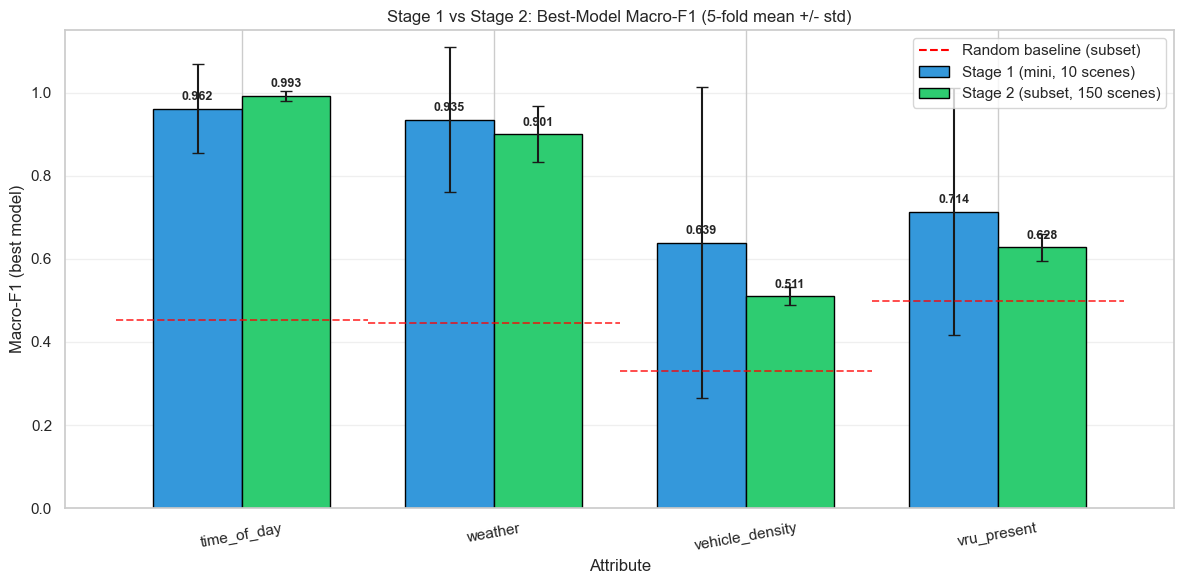

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(ATTRIBUTES)); w = 0.35
order = comparison.set_index('Attribute').reindex(ATTRIBUTES)
b1 = ax.bar(x - w/2, order['Mini F1'], w, yerr=order['Mini std'], capsize=4,
            label='Stage 1 (mini, 10 scenes)', color='#3498db', edgecolor='black')
b2 = ax.bar(x + w/2, order['Subset F1'], w, yerr=order['Subset std'], capsize=4,
            label='Stage 2 (subset, 150 scenes)', color='#2ecc71', edgecolor='black')
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.3f}',
                ha='center', fontsize=9, fontweight='bold')
for i, attr in enumerate(ATTRIBUTES):
    ax.hlines(s2_random.get(attr, np.nan), x[i]-0.5, x[i]+0.5,
              colors='red', linestyles='--', linewidth=1.4, alpha=0.7)
ax.plot([], [], color='red', linestyle='--', label='Random baseline (subset)')
ax.set_xlabel('Attribute'); ax.set_ylabel('Macro-F1 (best model)')
ax.set_title('Stage 1 vs Stage 2: Best-Model Macro-F1 (5-fold mean +/- std)')
ax.set_xticks(x); ax.set_xticklabels(ATTRIBUTES, rotation=10)
ax.set_ylim(0, 1.15); ax.legend(loc='upper right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(COMPARE_FIG_DIR / 'mini_vs_subset_headline.png', bbox_inches='tight', dpi=120)
plt.show()

## 8. Delta Plot — Where Did Scale Help Most?

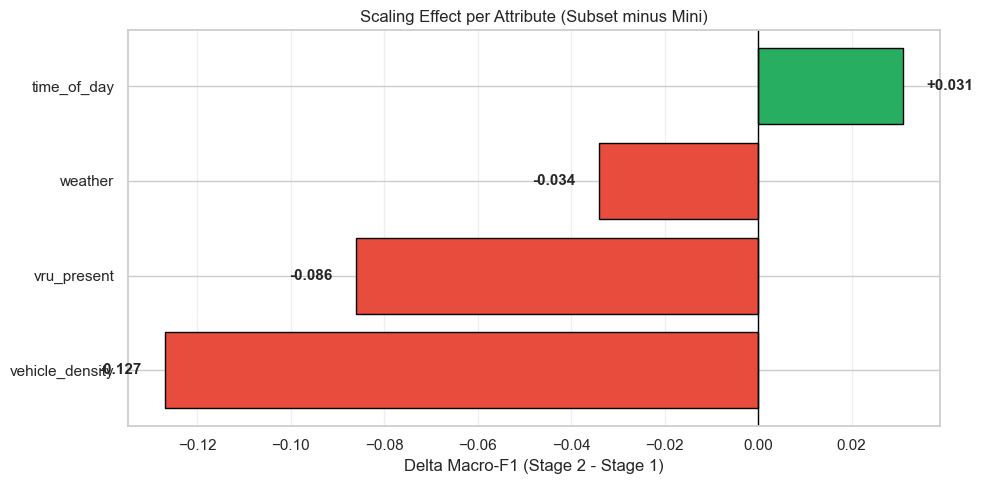

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
dd = comparison.sort_values('Delta F1')
colors = ['#e74c3c' if v < 0 else '#27ae60' for v in dd['Delta F1']]
bars = ax.barh(dd['Attribute'], dd['Delta F1'], color=colors, edgecolor='black')
for bar, v in zip(bars, dd['Delta F1']):
    ax.text(v + (0.005 if v >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{v:+.3f}', ha='left' if v >= 0 else 'right', va='center',
            fontsize=11, fontweight='bold')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Delta Macro-F1 (Stage 2 - Stage 1)')
ax.set_title('Scaling Effect per Attribute (Subset minus Mini)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(COMPARE_FIG_DIR / 'scaling_delta.png', bbox_inches='tight', dpi=120)
plt.show()

## 9. Stage 2 Confusion Matrices (5-fold out-of-fold, seed 42)

In k-fold CV every keyframe is tested exactly once across the folds, so aggregating all folds at a fixed seed yields a full-dataset out-of-fold confusion matrix.

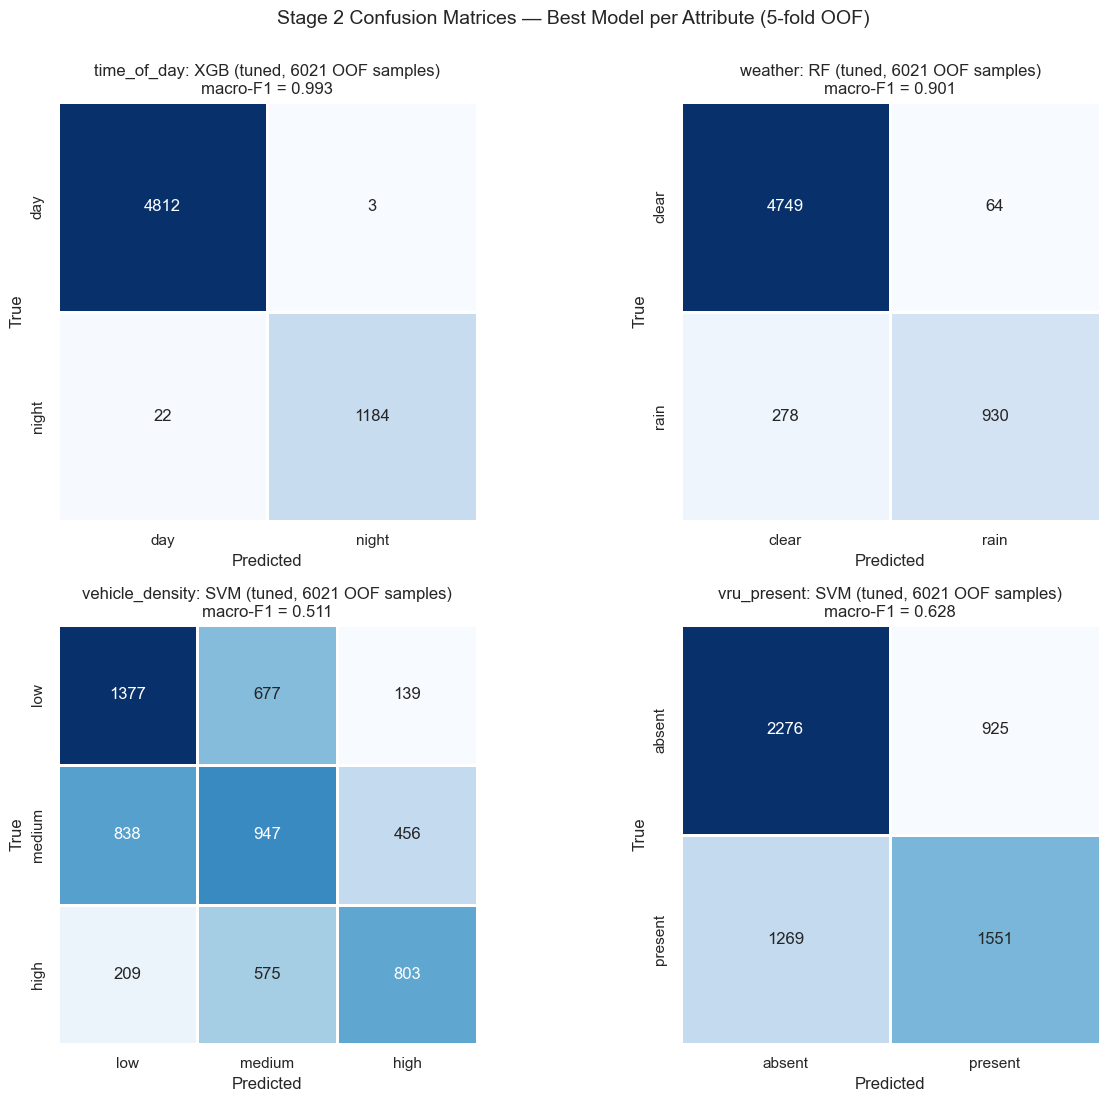

In [11]:
NAME_TO_FULL = {v: k for k, v in MODEL_DISPLAY.items()}
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for i, attr in enumerate(ATTRIBUTES):
    ax = axes[i // 2, i % 2]
    classes = CLASS_ORDERS[attr]
    best_short = stage2_best[stage2_best['attribute'] == attr]['best_model'].iloc[0]
    best_full  = NAME_TO_FULL[best_short]
    sub = df_preds[(df_preds['attribute'] == attr) & (df_preds['model'] == best_full) &
                   (df_preds['version'] == 'tuned') & (df_preds['seed'] == SEED_FOR_CM)]
    if len(sub) == 0:
        ax.text(0.5, 0.5, f'No predictions:\n{attr}/{best_full}', ha='center',
                va='center', transform=ax.transAxes); continue
    cm = confusion_matrix(sub['y_true'].values, sub['y_pred'].values, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=classes, yticklabels=classes, ax=ax, linewidths=1, square=True)
    f1 = stage2_best[stage2_best['attribute'] == attr]['macro_f1'].iloc[0]
    ax.set_title(f'{attr}: {best_short} (tuned, {len(sub)} OOF samples)\nmacro-F1 = {f1:.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Stage 2 Confusion Matrices — Best Model per Attribute (5-fold OOF)',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(COMPARE_FIG_DIR / 'stage2_confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()

## 10. Full Model x Attribute Comparison (both stages, tuned macro-F1)

In [12]:
s1_wide = stage1_tuned.reindex(columns=ATTRIBUTES)
s2_wide = stage2_tuned.reindex(columns=ATTRIBUTES)
combined = pd.concat({'Mini': s1_wide, 'Subset': s2_wide}, axis=1).round(3)
print('=== ALL MODELS x ALL ATTRIBUTES (tuned, macro-F1) ===\n')
print(combined)
combined.to_csv(COMPARE_METRICS_DIR / 'full_model_comparison.csv')
print(f'\nSaved -> {COMPARE_METRICS_DIR / "full_model_comparison.csv"}')

=== ALL MODELS x ALL ATTRIBUTES (tuned, macro-F1) ===

                 Mini                                          Subset          \
attribute time_of_day weather vehicle_density vru_present time_of_day weather   
model                                                                           
LogReg          0.865   0.791           0.639       0.714       0.993   0.858   
MLP             0.810   0.691           0.594       0.665       0.969   0.850   
RF              0.962   0.926           0.581       0.663       0.976   0.901   
SVM             0.815   0.935           0.595       0.667       0.978   0.876   
XGB             0.935   0.794           0.619       0.673       0.993   0.896   

                                       
attribute vehicle_density vru_present  
model                                  
LogReg              0.486       0.601  
MLP                 0.489       0.615  
RF                  0.442       0.599  
SVM                 0.511       0.628  
XGB             

## 11. Save Final Summary

In [13]:
summary = {
    'comparison_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'stage1_source':   STAGE1_SOURCE,
    'protocol':        'Both stages: 5-fold scene-aware CV, inner 3-fold tuning, seeds [42,7,123]',
    'stage1': {'dataset': 'v1.0-mini (10 scenes, ~404 keyframes)',
               'best_per_attribute': {r['attribute']: {'model': r['best_model'],
                   'macro_f1': round(r['macro_f1'], 3)} for _, r in stage1_best.iterrows()}},
    'stage2': {'dataset': 'v1.0-trainval 150-scene subset (~6,021 keyframes)',
               'best_per_attribute': {r['attribute']: {'model': r['best_model'],
                   'macro_f1': round(r['macro_f1'], 3)} for _, r in stage2_best.iterrows()}},
    'deltas': {r['Attribute']: {'delta_macro_f1': round(r['Delta F1'], 3),
               'relative_change_%': round(r['Rel change %'], 1)}
               for _, r in comparison.iterrows()},
}
with open(COMPARE_FINAL_DIR / 'mini_vs_subset_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Saved -> {COMPARE_FINAL_DIR / "mini_vs_subset_summary.json"}')
print(json.dumps(summary, indent=2))

Saved -> results\comparison\final\mini_vs_subset_summary.json
{
  "comparison_date": "2026-05-25 01:01:38",
  "stage1_source": "CSV (v1.0-mini re-run on this machine)",
  "protocol": "Both stages: 5-fold scene-aware CV, inner 3-fold tuning, seeds [42,7,123]",
  "stage1": {
    "dataset": "v1.0-mini (10 scenes, ~404 keyframes)",
    "best_per_attribute": {
      "time_of_day": {
        "model": "RF",
        "macro_f1": 0.962
      },
      "vehicle_density": {
        "model": "LogReg",
        "macro_f1": 0.639
      },
      "vru_present": {
        "model": "LogReg",
        "macro_f1": 0.714
      },
      "weather": {
        "model": "SVM",
        "macro_f1": 0.935
      }
    }
  },
  "stage2": {
    "dataset": "v1.0-trainval 150-scene subset (~6,021 keyframes)",
    "best_per_attribute": {
      "time_of_day": {
        "model": "XGB",
        "macro_f1": 0.993
      },
      "vehicle_density": {
        "model": "SVM",
        "macro_f1": 0.511
      },
      "vru_present": 

## 12. Final Verdict (threshold-driven)

In [14]:
print('=' * 95)
print('RESEARCH QUESTION')
print('=' * 95)
print('Q: How does classical-feature performance per attribute change from the small')
print('   10-scene pilot (Stage 1) to the 150-scene subset (Stage 2), under identical')
print('   5-fold scene-aware CV?')
print()

# Categorise by the ACTUAL computed deltas (no hardcoded narrative)
up    = comparison[comparison['Delta F1'] >  0.05]
flat  = comparison[(comparison['Delta F1'] >= -0.05) & (comparison['Delta F1'] <= 0.05)]
down  = comparison[comparison['Delta F1'] < -0.05]

print(f'Improved with scale ({len(up)}/4):')
for _, r in up.iterrows():
    print(f'  - {r["Attribute"]:18s} {r["Mini F1"]:.3f} -> {r["Subset F1"]:.3f}  ({r["Rel change %"]:+.1f}%)')
print(f'Stable / comparable ({len(flat)}/4):')
for _, r in flat.iterrows():
    print(f'  - {r["Attribute"]:18s} {r["Mini F1"]:.3f} -> {r["Subset F1"]:.3f}  ({r["Rel change %"]:+.1f}%)')
print(f'Lower at scale ({len(down)}/4):')
for _, r in down.iterrows():
    print(f'  - {r["Attribute"]:18s} {r["Mini F1"]:.3f} -> {r["Subset F1"]:.3f}  ({r["Rel change %"]:+.1f}%)')

# Variance contrast — the key mechanism — computed from the data
print()
print('Variance (std) contrast — Stage 1 vs Stage 2:')
for _, r in comparison.iterrows():
    print(f'  {r["Attribute"]:18s}  mini std={r["Mini std"]:.3f}   subset std={r["Subset std"]:.3f}')
print()
print('Interpretation is data-driven: where mini std is large (small-fold instability),')
print('mini point estimates are unreliable; the larger subset gives tight, trustworthy')
print('estimates. See written analysis for the full discussion.')

RESEARCH QUESTION
Q: How does classical-feature performance per attribute change from the small
   10-scene pilot (Stage 1) to the 150-scene subset (Stage 2), under identical
   5-fold scene-aware CV?

Improved with scale (0/4):
Stable / comparable (2/4):
  - time_of_day        0.962 -> 0.993  (+3.2%)
  - weather            0.935 -> 0.901  (-3.7%)
Lower at scale (2/4):
  - vehicle_density    0.639 -> 0.511  (-20.0%)
  - vru_present        0.714 -> 0.628  (-12.1%)

Variance (std) contrast — Stage 1 vs Stage 2:
  time_of_day         mini std=0.106   subset std=0.012
  vehicle_density     mini std=0.375   subset std=0.022
  vru_present         mini std=0.298   subset std=0.033
  weather             mini std=0.175   subset std=0.068

Interpretation is data-driven: where mini std is large (small-fold instability),
mini point estimates are unreliable; the larger subset gives tight, trustworthy
estimates. See written analysis for the full discussion.


In [15]:
import pandas as pd, json
from pathlib import Path

mini = pd.read_csv(Path('results/v1.0-mini/metrics/all_metrics.csv'))
sub  = pd.read_csv(Path('results/v1.0-trainval/metrics/all_metrics.csv'))

print('=== ROW COUNTS / CONFIG ===')
print('mini rows:', len(mini), '| subset rows:', len(sub))
print('\nmini fits per attribute x version:')
print(mini.groupby(['attribute','version']).size())

print('\n=== MINI WEATHER HANDLING (the key check) ===')
mw = mini[mini['attribute']=='weather']
print('mini weather rows:', len(mw), '| folds:', sorted(mw['fold'].unique()))
for f in sorted(mw['fold'].unique()):
    print(f'  fold {f}: {len(mw[mw.fold==f])} rows, macro_f1 range '
          f'{mw[mw.fold==f].macro_f1.min():.3f}-{mw[mw.fold==f].macro_f1.max():.3f}')

print('\n=== mini skipped combos ===')
sk = Path('results/v1.0-mini/metrics/skipped_combos.json')
print(json.load(open(sk)) if sk.exists() else 'NO skipped_combos.json found')

print('\n=== NaN / degenerate check (both stages) ===')
for name, d in [('mini',mini),('subset',sub)]:
    print(f'{name}: NaN macro_f1={d.macro_f1.isna().sum()}, '
          f'exactly 1.0={(d.macro_f1==1.0).sum()}, exactly 0.0={(d.macro_f1==0.0).sum()}')

print('\n=== BASELINE BEAT CHECK (subset best vs random) ===')
sb = pd.read_csv('results/v1.0-trainval/metrics/baseline_metrics.csv')
for attr in ['time_of_day','weather','vehicle_density','vru_present']:
    best = sub[(sub.attribute==attr)&(sub.version=='tuned')].groupby('model').macro_f1.mean().max()
    rand = sb[(sb.attribute==attr)&(sb.baseline=='random')].macro_f1.mean()
    print(f'  {attr:18s} best={best:.3f}  random={rand:.3f}  {"BEATS" if best>rand else "FAILS"}')

=== ROW COUNTS / CONFIG ===
mini rows: 1140 | subset rows: 600

mini fits per attribute x version:
attribute        version
time_of_day      base       150
                 tuned      150
vehicle_density  base       150
                 tuned      150
vru_present      base       150
                 tuned      150
weather          base       120
                 tuned      120
dtype: int64

=== MINI WEATHER HANDLING (the key check) ===
mini weather rows: 240 | folds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  fold 1: 60 rows, macro_f1 range 0.339-1.000
  fold 2: 60 rows, macro_f1 range 0.433-1.000
  fold 3: 60 rows, macro_f1 range 0.404-1.000
  fold 4: 60 rows, macro_f1 range 0.279-1.000

=== mini skipped combos ===
[{'fold': 0, 'attribute': 'weather', 'reason': 'train_single_class', 'n_train_classes': 1, 'n_test_classes': 2}]

=== NaN / degenerate check (both stages) ===
mini: NaN macro_f1=0, exactly 1.0=593, exactly 0.0=0
subset: NaN macro_f1=0, exactly 1.0=41, exactly 0.

In [16]:
import pandas as pd
from pathlib import Path

mini = pd.read_csv('results/v1.0-mini/metrics/all_metrics.csv')
sub  = pd.read_csv('results/v1.0-trainval/metrics/all_metrics.csv')

# (3) Where are mini's perfect scores? Degenerate beyond weather?
print('=== MINI perfect-score (1.000) count by attribute ===')
perf = mini[mini['macro_f1']==1.0]
print(perf.groupby('attribute').size())
print('\nMini macro_f1 by attribute (mean / max / %perfect):')
for a in mini['attribute'].unique():
    d = mini[mini.attribute==a]['macro_f1']
    print(f'  {a:18s} mean={d.mean():.3f} max={d.max():.3f} %perfect={100*(d==1.0).mean():.0f}%')

# (2) Subset best vs BOTH baselines (random AND majority)
print('\n=== SUBSET best-tuned vs random AND majority ===')
sb = pd.read_csv('results/v1.0-trainval/metrics/baseline_metrics.csv')
for a in ['time_of_day','weather','vehicle_density','vru_present']:
    best = sub[(sub.attribute==a)&(sub.version=='tuned')].groupby('model').macro_f1.mean().max()
    rnd  = sb[(sb.attribute==a)&(sb.baseline=='random')].macro_f1.mean()
    maj  = sb[(sb.attribute==a)&(sb.baseline=='majority')].macro_f1.mean()
    print(f'  {a:18s} best={best:.3f} | random={rnd:.3f} {"OK" if best>rnd else "FAIL"} | majority={maj:.3f} {"OK" if best>maj else "FAIL"}')

# (1) Model file count vs fits
mdir = Path('models/v1.0-trainval')
pkls = list(mdir.rglob('*.pkl')) if mdir.exists() else []
print(f'\n=== Model files: {len(pkls)} (metrics rows: {len(sub)}) ===')
# sample a few names to see the pattern
for p in pkls[:6]: print('  ', p.name)

=== MINI perfect-score (1.000) count by attribute ===
attribute
time_of_day        195
vehicle_density    120
vru_present        120
weather            158
dtype: int64

Mini macro_f1 by attribute (mean / max / %perfect):
  time_of_day        mean=0.875 max=1.000 %perfect=65%
  vehicle_density    mean=0.609 max=1.000 %perfect=40%
  vru_present        mean=0.681 max=1.000 %perfect=40%
  weather            mean=0.821 max=1.000 %perfect=66%

=== SUBSET best-tuned vs random AND majority ===
  time_of_day        best=0.993 | random=0.452 OK | majority=0.444 OK
  weather            best=0.901 | random=0.446 OK | majority=0.443 OK
  vehicle_density    best=0.511 | random=0.330 OK | majority=0.168 OK
  vru_present        best=0.628 | random=0.498 OK | majority=0.346 OK

=== Model files: 600 (metrics rows: 600) ===
   LogisticRegression_base_seed123_fold0.pkl
   LogisticRegression_base_seed123_fold1.pkl
   LogisticRegression_base_seed123_fold2.pkl
   LogisticRegression_base_seed123_fold3.pkl
  

In [17]:
from pathlib import Path
from datetime import datetime
import pandas as pd

mdir = Path('models/v1.0-trainval')

# 1) The LAST attribute/fold in the loop = vru_present, fold 4. If these exist + are recent, the run finished.
print('=== vru_present fold-4 models (the final fits 571-600) ===')
last = sorted(mdir.rglob('*vru_present*fold4*.pkl')) if (mdir/'vru_present').exists() else \
       sorted((mdir/'vru_present').glob('*fold4*.pkl'))
# fallback: vru_present folder, fold4 files
vru = mdir/'vru_present'
last = sorted(vru.glob('*fold4*.pkl'))
print(f'Found {len(last)} vru_present fold-4 models (expect 10: 5 models x 2 versions x ... )')
for p in last:
    mtime = datetime.fromtimestamp(p.stat().st_mtime)
    print(f'  {mtime:%Y-%m-%d %H:%M:%S}  {p.name}')

=== vru_present fold-4 models (the final fits 571-600) ===
Found 30 vru_present fold-4 models (expect 10: 5 models x 2 versions x ... )
  2026-05-24 17:09:51  LogisticRegression_base_seed123_fold4.pkl
  2026-05-24 17:09:47  LogisticRegression_base_seed42_fold4.pkl
  2026-05-24 17:09:49  LogisticRegression_base_seed7_fold4.pkl
  2026-05-24 17:10:16  LogisticRegression_tuned_seed123_fold4.pkl
  2026-05-24 17:09:59  LogisticRegression_tuned_seed42_fold4.pkl
  2026-05-24 17:10:07  LogisticRegression_tuned_seed7_fold4.pkl
  2026-05-24 18:56:16  MLP_base_seed123_fold4.pkl
  2026-05-24 18:55:59  MLP_base_seed42_fold4.pkl
  2026-05-24 18:56:06  MLP_base_seed7_fold4.pkl
  2026-05-24 18:59:52  MLP_tuned_seed123_fold4.pkl
  2026-05-24 18:57:41  MLP_tuned_seed42_fold4.pkl
  2026-05-24 18:58:46  MLP_tuned_seed7_fold4.pkl
  2026-05-24 18:25:18  RandomForest_base_seed123_fold4.pkl
  2026-05-24 18:25:13  RandomForest_base_seed42_fold4.pkl
  2026-05-24 18:25:16  RandomForest_base_seed7_fold4.pkl
  2026

In [18]:
from pathlib import Path
from datetime import datetime
import pandas as pd

csv = Path('results/v1.0-trainval/metrics/all_metrics.csv')
print('all_metrics.csv last modified:', datetime.fromtimestamp(csv.stat().st_mtime))

df = pd.read_csv(csv)
# The very last rows should be vru_present, fold 4 (the end of the loop)
print('\nLast 6 rows of the metrics file:')
print(df.tail(6)[['attribute','model','version','seed','fold','macro_f1']].to_string(index=False))

# Count the final-fold vru_present fits specifically
final = df[(df.attribute=='vru_present') & (df.fold==4)]
print(f'\nvru_present fold-4 fits in CSV: {len(final)} (expect 30: 5 models x 2 versions x 3 seeds)')

all_metrics.csv last modified: 2026-05-24 18:59:52.840288

Last 6 rows of the metrics file:
  attribute model version  seed  fold  macro_f1
vru_present   MLP    base    42     4  0.626371
vru_present   MLP    base     7     4  0.623357
vru_present   MLP    base   123     4  0.608227
vru_present   MLP   tuned    42     4  0.619012
vru_present   MLP   tuned     7     4  0.628368
vru_present   MLP   tuned   123     4  0.608227

vru_present fold-4 fits in CSV: 30 (expect 30: 5 models x 2 versions x 3 seeds)


In [2]:
import os, json
import pandas as pd
from pathlib import Path

def find_project_root():
    p = Path.cwd().resolve()
    for c in [p, *p.parents]:
        if (c/'README.md').exists() and (c/'notebooks').exists():
            return c
    raise FileNotFoundError('Project root not found')
os.chdir(find_project_root())
print('Working dir:', Path.cwd())   # should show ...\nuscenes-scene-classification-ml

for s in ['v1.0-mini','v1.0-trainval']:
    base = Path(f'results/{s}')
    m = pd.read_csv(base/'metrics'/'all_metrics.csv')
    try: sk = len(json.load(open(base/'metrics'/'skipped_combos.json')))
    except: sk = '?'
    try: preds = len(pd.read_csv(base/'predictions'/'predictions_test.csv'))
    except: preds = 'n/a'
    print(f'{s}: {len(m)} metric rows | {sk} skipped | {preds} predictions | '
          f'folds={sorted(m.fold.unique())} | models={sorted(m.model.unique())} | '
          f'versions={sorted(m.version.unique())}')

Working dir: C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml
v1.0-mini: 1140 metric rows | 1 skipped | 46050 predictions | folds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] | models=['LogisticRegression', 'MLP', 'RandomForest', 'SVM_RBF', 'XGBoost'] | versions=['base', 'tuned']
v1.0-trainval: 600 metric rows | 0 skipped | 722520 predictions | folds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] | models=['LogisticRegression', 'MLP', 'RandomForest', 'SVM_RBF', 'XGBoost'] | versions=['base', 'tuned']


In [4]:
import joblib, pandas as pd
from pathlib import Path

# Load a saved best model (dict: {'model', 'label_encoder'})
bundle = joblib.load('models/v1.0-trainval/time_of_day/XGBoost_tuned_seed42_fold0.pkl')
model, le = bundle['model'], bundle['label_encoder']

# Load a few test feature rows and predict (demonstrates the model works)
feats = pd.read_csv('data/processed/v1.0-trainval/features/features_full.csv').head(5)
feat_cols = [c for c in feats.columns if c.startswith(('hog_','color_','lbp_','photo_'))]
preds = le.inverse_transform(model.predict(feats[feat_cols].values))
print('Sample predictions:', preds)

Sample predictions: ['day' 'day' 'day' 'day' 'day']


In [4]:
import os
import pandas as pd
from pathlib import Path

def find_project_root():
    p = Path.cwd().resolve()
    for c in [p, *p.parents]:
        if (c/'README.md').exists() and (c/'notebooks').exists():
            return c
    raise FileNotFoundError('Project root not found')
os.chdir(find_project_root())

df = pd.read_csv('results/v1.0-trainval/metrics/all_metrics.csv')
print('Columns:', list(df.columns))

Columns: ['accuracy', 'macro_f1', 'weighted_f1', 'macro_precision', 'macro_recall', 'auc', 'attribute', 'model', 'version', 'seed', 'fold', 'best_params']


---
## Summary

Both stages now use identical 5-fold scene-aware CV, so this comparison is like-for-like. Stage 1 documents the failures and the weather-untestability limitation; Stage 2 tests whether scaling resolves them. Cross-stage comparison is descriptive (different datasets -> unpaired); model-level significance within each stage is in Stage 1's 08b.

### Files produced
- `results/comparison/metrics/mini_vs_subset_headline.csv`
- `results/comparison/metrics/full_model_comparison.csv`
- `results/comparison/final/mini_vs_subset_summary.json`
- `results/comparison/figures/{mini_vs_subset_headline,scaling_delta,stage2_confusion_matrices}.png`

### Next
Revise `report_template.md` to two-stage framing; fill §4.3 distributions; verify Stage 1 source banner above reads "CSV (re-run verified)" before final submission.